In [6]:
import sys
import os

# Add the project root (where the nn/ folder lives) to the import path
sys.path.insert(0, os.path.abspath('..'))

# Now you can import from nn
from nn import network2
from nn import mnist_loader

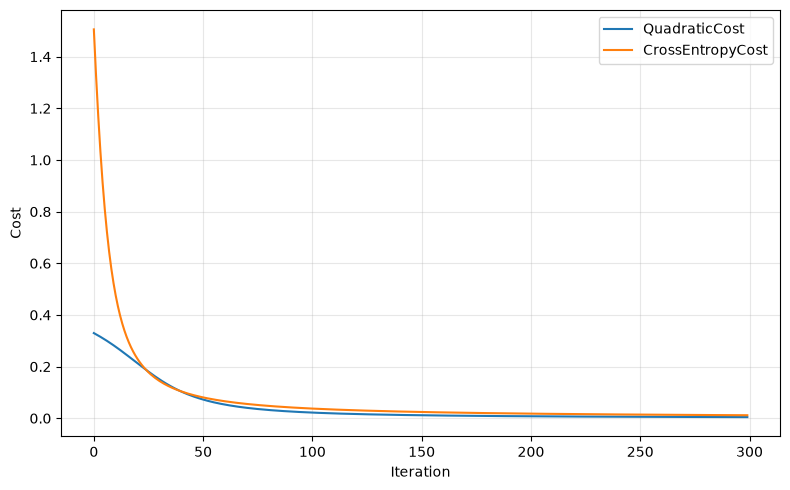

In [15]:
# PART 1 - recreate the cost graphs

import contextlib
import io
import numpy as np
import matplotlib.pyplot as plt

net1 = network2.Network([1, 1], cost=network2.QuadraticCost)
net2 = network2.Network([1, 1], cost=network2.CrossEntropyCost)

training_data = [(np.array([[1.0]]), np.array([[0.0]]))]
initial_weights = [np.array([[0.6]])]
initial_biases = [np.array([[0.9]])]
net1.weights = [weight.copy() for weight in initial_weights]
net1.biases = [bias.copy() for bias in initial_biases]
net2.weights = [weight.copy() for weight in initial_weights]
net2.biases = [bias.copy() for bias in initial_biases]

costs1 = []
costs2 = []
with contextlib.redirect_stdout(io.StringIO()):
    for _ in range(300):
        (_, _, train_cost, _) = net1.SGD(training_data, 1, 1, 0.15, 0.0, monitor_training_cost=True)
        costs1.append(train_cost[0])
        (_, _, train_cost, _) = net2.SGD(training_data, 1, 1, 0.15, 0.0, monitor_training_cost=True)
        costs2.append(train_cost[0])

plt.figure(figsize=(8, 5))
plt.plot(costs1, label='QuadraticCost')
plt.plot(costs2, label='CrossEntropyCost')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# PART 2 - Overfitting and regularization

import contextlib
import importlib
import os

importlib.reload(network2)
training_data, validation_data, test_data = mnist_loader.load_data_wrapper('../nn/mnist.pkl.gz')
training_data = list(training_data)
validation_data = list(validation_data)
test_data = list(test_data)

experiment_configs = [
    ("A", training_data[:1000], 0),
    ("B", training_data[:1000], 5),
    ("C", training_data, 5),
]

results = {}
for experiment, experiment_data, lmbda in experiment_configs:
    experiment_net = network2.Network(
        [784, 30, 10],
        cost=network2.CrossEntropyCost
    )
    experiment_net.large_weight_initializer()

    with open(os.devnull, "w") as training_log:
        with contextlib.redirect_stdout(training_log):
            evaluation_cost, evaluation_accuracy, training_cost, training_accuracy = experiment_net.SGD(
                experiment_data,
                epochs=100,
                mini_batch_size=10,
                eta=0.5,
                evaluation_data=validation_data,
                lmbda=lmbda,
                monitor_training_cost=True,
                monitor_training_accuracy=True,
                monitor_evaluation_cost=True,
                monitor_evaluation_accuracy=True
            )

    results[experiment] = {
        "training_cost": training_cost,
        "training_accuracy": training_accuracy,
        "evaluation_cost": evaluation_cost,
        "evaluation_accuracy": evaluation_accuracy,
        "training_size": len(experiment_data),
        "evaluation_size": len(validation_data),
        "lmbda": lmbda,
    }
    print(f"Experiment {experiment} complete: {len(training_cost)} epochs, lambda={lmbda}")

Experiment A complete: 100 epochs, lambda=0
Experiment B complete: 100 epochs, lambda=5
Experiment C complete: 100 epochs, lambda=5


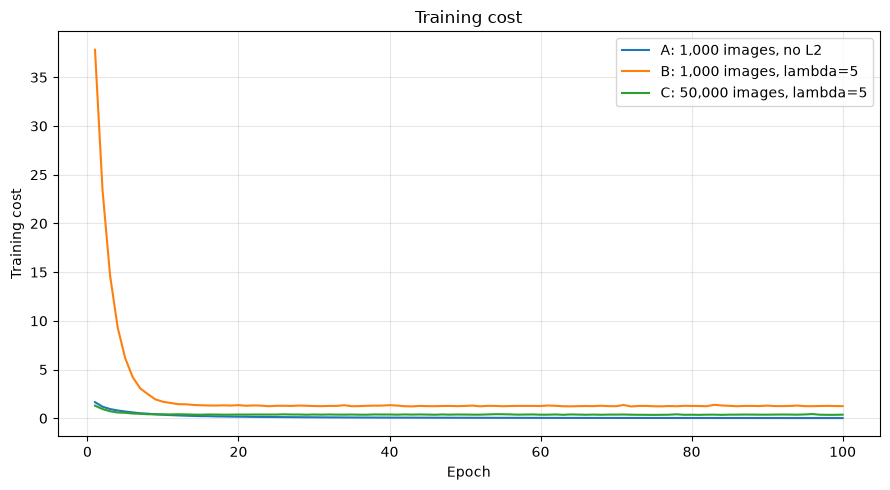

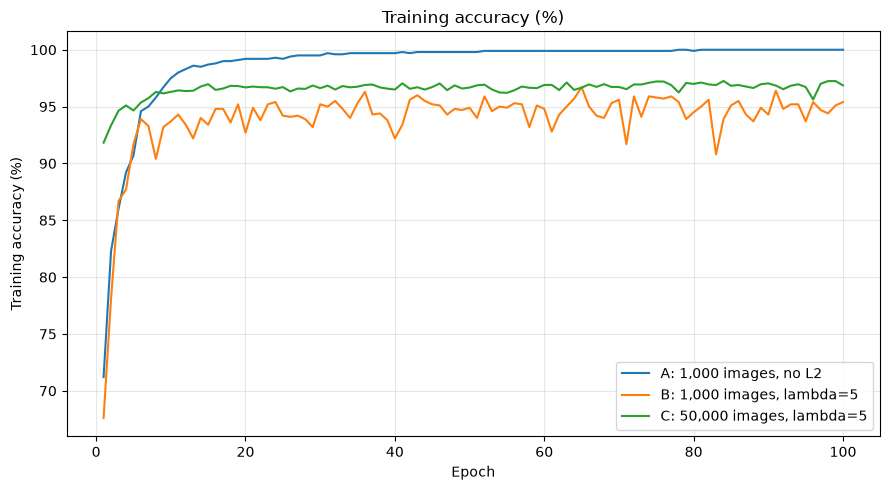

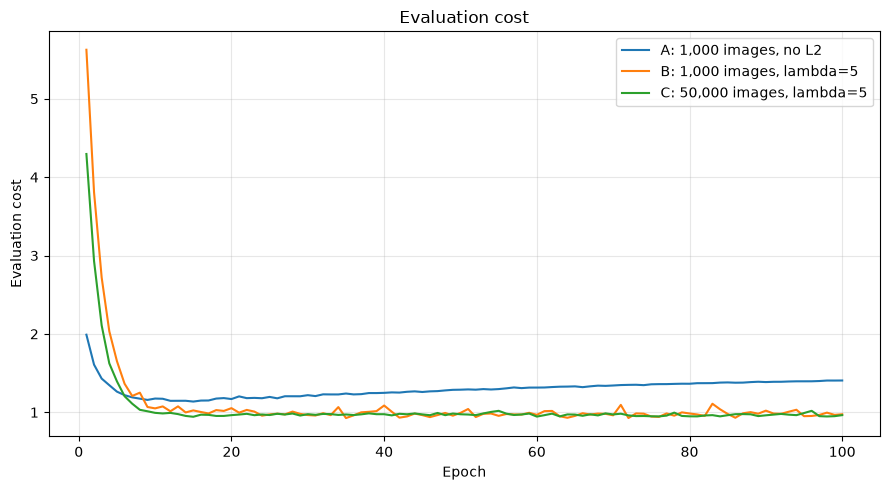

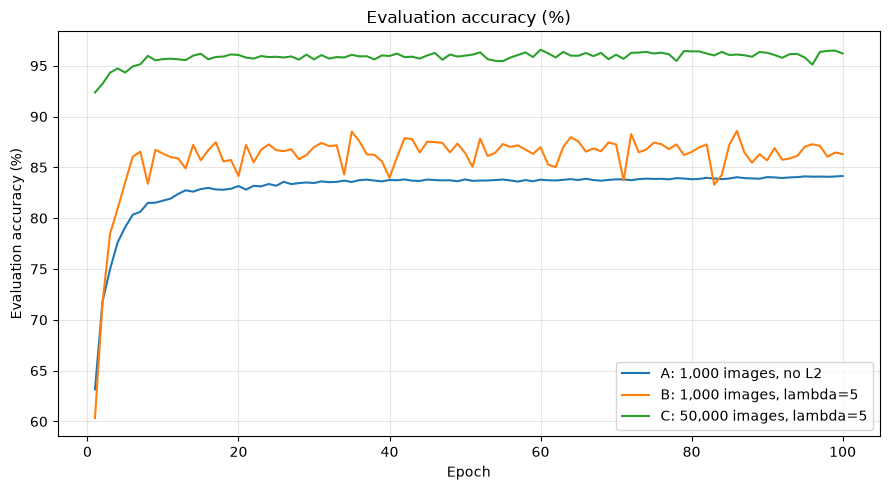

In [16]:
# Plot the four metrics for experiments A, B, and C

import matplotlib.pyplot as plt

required_experiments = {"A", "B", "C"}
if not required_experiments.issubset(results):
    raise RuntimeError("Run the experiment cell first to populate results for A, B, and C.")

experiment_labels = {
    "A": "A: 1,000 images, no L2",
    "B": "B: 1,000 images, lambda=5",
    "C": "C: 50,000 images, lambda=5",
}
metric_plots = [
    ("training_cost", "Training cost", False),
    ("training_accuracy", "Training accuracy (%)", True),
    ("evaluation_cost", "Evaluation cost", False),
    ("evaluation_accuracy", "Evaluation accuracy (%)", True),
]

for metric, y_label, is_accuracy in metric_plots:
    plt.figure(figsize=(9, 5))
    for experiment in ("A", "B", "C"):
        values = results[experiment][metric]
        if is_accuracy:
            denominator = results[experiment]["training_size"] if metric == "training_accuracy" else results[experiment]["evaluation_size"]
            values = [100 * value / denominator for value in values]
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=experiment_labels[experiment])

    plt.xlabel("Epoch")
    plt.ylabel(y_label)
    plt.title(y_label)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()